# Experiment L: Verbalizer (Prompt-based Classification)

Instead of pooling hidden states through a classifier head, use the
pretrained MLM head as a prompt-based classifier.

**Approach:**
1. Frame the task as a QA cloze: `"Is this text patronising? {text} Answer: [MASK]"`
2. Pass through `RobertaForMaskedLM` to get vocab logits at the `[MASK]` position
3. Score = `log P("Yes" | mask) − log P("No" | mask)`
4. Train with `BCEWithLogitsLoss` — the log-odds output is directly compatible

**Key advantages** of Yes/No verbalizers over adjective-based ones:
- "Yes" and "No" are guaranteed single tokens — no subword fragmentation
- The question template directly describes the classification task
- The MLM head's prior for Yes/No after "Answer:" is strong and well-calibrated

Hyperparameters searched: LR, warmup, weight decay, label smoothing,
verbalizer variant (Yes/No, yes/no, True/False), question phrasing.

In [1]:
import os
import sys
import random
import logging
import gc
import json

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import classification_report
from transformers import AutoTokenizer
import optuna
from optuna.visualization.matplotlib import (
    plot_optimization_history,
    plot_param_importances,
    plot_parallel_coordinate,
)
import matplotlib.pyplot as plt

sys.path.insert(0, "..")
from utils.data import load_data
from utils.split import split_train_val
from utils.pcl_dataset import PCLVerbalizerDataset
from utils.pcl_deberta import PCLVerbalizer
from utils.optim import compute_pos_weight
from utils.training_loop import train_model
from utils.eval import evaluate
from utils.losses import FocalLoss
from utils.augmentation import backtranslate

SEED = 42
DATA_DIR = "../data"
OUT_DIR = "out"
MODEL_OUT_DIR = OUT_DIR
MODEL_NAME = "roberta-large"
MAX_LENGTH = 256
VAL_FRACTION = 0.15
BATCH_SIZE = 32
N_TRIALS = 8
NUM_EPOCHS = 12
PATIENCE = 4
N_EVAL_STEPS = 35
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIVOT_LANGS = ["ru", "fr", "fi", "de"]   # structurally varied, high-quality Helsinki-NLP models
LEVEL_TO_LANGS = {
    1: ["fr"],
    2: ["fr", "fi"],
    3: ["fr", "fi", "de"],
    4: PIVOT_LANGS,
}

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s:\t%(message)s")
LOG = logging.getLogger(__name__)
LOG.info(f"Device: {DEVICE}")
os.makedirs(OUT_DIR, exist_ok=True)

if os.getlogin() == "jc4423":
    LOG.info("Running on lab machines, changing caches and model out dir")
    os.environ["HF_HOME"] = "/vol/bitbucket/jc4423/.cache/huggingface"
    os.environ["TRANSFORMERS_CACHE"] = "/vol/bitbucket/jc4423/.cache/huggingface"
    os.environ["HF_DATASETS_CACHE"] = "/vol/bitbucket/jc4423/.cache/huggingface"
    os.environ["PIP_CACHE_DIR"] = "/vol/bitbucket/jc4423/.cache/pip"
    os.environ["XDG_CACHE_HOME"] = "/vol/bitbucket/jc4423/.cache"
    MODEL_OUT_DIR = "/vol/bitbucket/jc4423/models/"

/vol/bitbucket/jc4423/mlenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-03-03 21:54:44,533 INFO:	Device: cuda
2026-03-03 21:54:44,539 INFO:	Running on lab machines, changing caches and model out dir


## 1. Data Loading

In [2]:
train_df, dev_df = load_data(DATA_DIR)
train_sub_df, val_sub_df = split_train_val(train_df, val_frac=VAL_FRACTION, seed=SEED)
tokeniser = AutoTokenizer.from_pretrained(MODEL_NAME)
LOG.info(f"Train: {len(train_sub_df)}, Val: {len(val_sub_df)}, Dev: {len(dev_df)}")

2026-03-03 21:54:44,816 INFO:	Train/val split: 7118 train, 1257 val (val_frac=0.15)
2026-03-03 21:54:44,817 INFO:	Train, val positive count: 675, 119
2026-03-03 21:54:44,968 INFO:	HTTP Request: HEAD https://huggingface.co/roberta-large/resolve/main/config.json "HTTP/1.1 200 OK"
2026-03-03 21:54:45,111 INFO:	HTTP Request: HEAD https://huggingface.co/roberta-large/resolve/main/tokenizer_config.json "HTTP/1.1 200 OK"
2026-03-03 21:54:45,476 INFO:	HTTP Request: GET https://huggingface.co/api/models/roberta-large/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 307 Temporary Redirect"
2026-03-03 21:54:45,570 INFO:	HTTP Request: GET https://huggingface.co/api/models/FacebookAI/roberta-large/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-03-03 21:54:45,668 INFO:	HTTP Request: GET https://huggingface.co/api/models/roberta-large/tree/main?recursive=true&expand=false "HTTP/1.1 307 Temporary Redirect"
2026-03-03 21:54:45,77

## 2. Verbalizer & Template Setup

The verbalizer maps binary classes to Yes/No tokens.
The main hyperparameter is the **question phrasing** — how we frame
the PCL detection task as a cloze question for the MLM head.

Three verbalizer variants (casing/wording) × four question templates
are searched jointly by Optuna.

In [3]:
pcl_mask = train_sub_df["binary_label"] == 1
pcl_texts = train_sub_df.loc[pcl_mask, "text"].tolist()

bt_texts = {}   # dict[lang -> list[str]]
for lang in PIVOT_LANGS:
    LOG.info(f"Back-translating {len(pcl_texts)} PCL paragraphs via {lang} pivot...")
    bt_texts[lang] = backtranslate(pcl_texts, pivot_lang=lang, device=DEVICE, batch_size=16)
    gc.collect()
    torch.cuda.empty_cache()

LOG.info("All back-translations complete.")

2026-03-03 21:54:46,071 INFO:	Back-translating 675 PCL paragraphs via ru pivot...
2026-03-03 21:54:46,331 INFO:	Back-translating 675 PCL paragraphs via fr pivot...
2026-03-03 21:54:46,549 INFO:	Back-translating 675 PCL paragraphs via fi pivot...
2026-03-03 21:54:46,784 INFO:	Back-translating 675 PCL paragraphs via de pivot...
2026-03-03 21:54:47,000 INFO:	All back-translations complete.


In [4]:
from torch.utils.data import DataLoader

# --- Define verbalizer variants ---
# Each entry: (name, positive_words, negative_words)
# Yes/No are guaranteed single tokens in SentencePiece.
VERBALIZER_SETS = [
    ("Yes_No",     ["Yes"],  ["No"]),
    ("yes_no",     ["yes"],  ["no"]),
    ("True_False", ["True"], ["False"]),
    ("true_false", ["true"], ["false"]),
]

# --- Question-style templates ---
# The question phrasing is the main thing being searched.
# {text} = input paragraph, {mask} = single [MASK] token.
TEMPLATE_OPTIONS = [
    'Is the following text patronising or condescending? "{text}" Answer: {mask}',
    'Does the author of this text sound patronising or condescending? "{text}" Answer: {mask}',
    'Is this text talking down to people? "{text}" Answer: {mask}',
    'Does the following text contain patronising language? "{text}" Answer: {mask}',
]


def words_to_first_subword_ids(words: list[str]) -> list[int]:
    """Convert words to their first subword token IDs."""
    ids = []
    for w in words:
        subtokens = tokeniser.encode(w, add_special_tokens=False)
        ids.append(subtokens[0])
        n_sub = len(subtokens)
        decoded = tokeniser.decode([subtokens[0]])
        flag = " Single token" if n_sub == 1 else f" {n_sub} subwords, using first ('{decoded}')"
        LOG.info(f"    '{w}' -> id {subtokens[0]}{flag}")
    return ids


# Pre-compute all verbalizer tokenisations and log diagnostics
VERBALIZER_CACHE: dict[str, tuple[list[int], list[int]]] = {}
for name, pos_words, neg_words in VERBALIZER_SETS:
    LOG.info(f"Verbalizer '{name}':")
    pos_ids = words_to_first_subword_ids(pos_words)
    neg_ids = words_to_first_subword_ids(neg_words)
    VERBALIZER_CACHE[name] = (pos_ids, neg_ids)

# Summary
print(f"\n{'Verbalizer':<12} pos_id  neg_id")
print("-" * 35)
for name, (p, n) in VERBALIZER_CACHE.items():
    print(f"{name:<12} {p}     {n}")

print(f"\nTemplates ({len(TEMPLATE_OPTIONS)}):")
for i, t in enumerate(TEMPLATE_OPTIONS):
    preview = t.format(text="...", mask="[MASK]")
    print(f"  [{i}] {preview}")


def make_verbalizer_aug_dataloaders(
    template: str,
    aug_level: int = 4,
) -> tuple[DataLoader, DataLoader, DataLoader]:
    """Create DataLoaders with the verbalizer template applied (single [MASK])."""
    assert aug_level in LEVEL_TO_LANGS, f"Invalid augmentation level {aug_level}"
    def make_ds(df):
        return PCLVerbalizerDataset(
            texts=df["text"].tolist(),
            labels=df["binary_label"].tolist(),
            max_length=MAX_LENGTH,
            tokeniser=tokeniser,
            template=template,
        )

    aug_langs = LEVEL_TO_LANGS[aug_level]
    aug_texts = []
    for lang in aug_langs:
        aug_texts.extend(bt_texts[lang])
    aug_df = pd.DataFrame({"text": aug_texts, "binary_label": 1})
    train_sub_aug_df = pd.concat([train_sub_df, aug_df])
    train_ds = make_ds(train_sub_aug_df)
    val_ds = make_ds(val_sub_df)
    dev_ds = make_ds(dev_df)
    print(f"Augmentation level {aug_level}, old train size: {len(train_sub_df)}, new train size: {len(train_sub_aug_df)}")

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    dev_loader = DataLoader(dev_ds, batch_size=BATCH_SIZE, shuffle=False)

    return train_loader, val_loader, dev_loader

2026-03-03 21:54:47,020 INFO:	Verbalizer 'Yes_No':
2026-03-03 21:54:47,023 INFO:	    'Yes' -> id 9904 Single token
2026-03-03 21:54:47,024 INFO:	    'No' -> id 3084 Single token
2026-03-03 21:54:47,025 INFO:	Verbalizer 'yes_no':
2026-03-03 21:54:47,026 INFO:	    'yes' -> id 10932 Single token
2026-03-03 21:54:47,027 INFO:	    'no' -> id 2362 Single token
2026-03-03 21:54:47,028 INFO:	Verbalizer 'True_False':
2026-03-03 21:54:47,030 INFO:	    'True' -> id 36948 Single token
2026-03-03 21:54:47,031 INFO:	    'False' -> id 46659 Single token
2026-03-03 21:54:47,032 INFO:	Verbalizer 'true_false':
2026-03-03 21:54:47,034 INFO:	    'true' -> id 29225 Single token
2026-03-03 21:54:47,035 INFO:	    'false' -> id 22303 Single token



Verbalizer   pos_id  neg_id
-----------------------------------
Yes_No       [9904]     [3084]
yes_no       [10932]     [2362]
True_False   [36948]     [46659]
true_false   [29225]     [22303]

Templates (4):
  [0] Is the following text patronising or condescending? "..." Answer: [MASK]
  [1] Does the author of this text sound patronising or condescending? "..." Answer: [MASK]
  [2] Is this text talking down to people? "..." Answer: [MASK]
  [3] Does the following text contain patronising language? "..." Answer: [MASK]


## 3. Hyperparameter Search

In [5]:
EXP_NAME = "N_verbalizer"

# --- Fixed HPs (stable across prior experiments) ---
WARMUP_FRACTION = 0.06
LABEL_SMOOTHING = 0.0


def objective(trial: optuna.trial.Trial) -> float:
    # Searched HPs
    lr              = trial.suggest_float("lr", 2e-6, 2e-5, log=True)
    weight_decay    = trial.suggest_float("weight_decay", 5e-4, 5e-3, log=True)
    head_lr_mult    = trial.suggest_categorical("head_lr_multiplier", [1, 5, 10])
    verbalizer_name = trial.suggest_categorical("verbalizer", [v[0] for v in VERBALIZER_SETS])
    template_idx    = trial.suggest_categorical("template_idx", list(range(len(TEMPLATE_OPTIONS))))
    gamma           = trial.suggest_categorical("gamma", [0.5, 1.0, 2.0])
    aug_level       = trial.suggest_categorical("aug_level", [1, 2, 4])

    template = TEMPLATE_OPTIONS[template_idx]
    pos_ids, neg_ids = VERBALIZER_CACHE[verbalizer_name]

    LOG.info(f"[{EXP_NAME}] Trial {trial.number}: lr={lr:.2e}, "
             f"verbalizer={verbalizer_name}, template={template_idx}, "
             f"head_lr_mult={head_lr_mult}, weight_decay={weight_decay:.2e}, "
             f"gamma={gamma}")

    # Dataloaders only depend on template (single [MASK]); verbalizer IDs go to the model
    train_loader, val_loader, dev_loader = make_verbalizer_aug_dataloaders(template, aug_level=aug_level)

    model = PCLVerbalizer(
        pos_verbalizer_ids=pos_ids,
        neg_verbalizer_ids=neg_ids,
        model_name=MODEL_NAME,
        gradient_checkpointing=True,
        cache_dir="/vol/bitbucket/jc4423/.cache/huggingface"
    ).to(DEVICE)

    pos_weight = compute_pos_weight(train_sub_df, DEVICE)
    criterion = FocalLoss(gamma=gamma, pos_weight=pos_weight)

    results = train_model(
        model=model, device=DEVICE,
        train_loader=train_loader, val_loader=val_loader, dev_loader=dev_loader,
        pos_weight=pos_weight, lr=lr, weight_decay=weight_decay,
        num_epochs=NUM_EPOCHS, warmup_fraction=WARMUP_FRACTION,
        patience=PATIENCE, head_lr_multiplier=head_lr_mult,
        label_smoothing=LABEL_SMOOTHING, eval_every_n_steps=N_EVAL_STEPS,
        trial=trial, criterion=criterion,
    )

    trial.set_user_attr("best_val_f1",    results["best_val_f1"])
    trial.set_user_attr("best_threshold", results["best_threshold"])
    trial.set_user_attr("dev_f1",         results["dev_metrics"]["f1"])
    trial.set_user_attr("dev_precision",  results["dev_metrics"]["precision"])
    trial.set_user_attr("dev_recall",     results["dev_metrics"]["recall"])

    try:
        prev_best = trial.study.best_value
    except ValueError:
        prev_best = -float("inf")
    if results["best_val_f1"] > prev_best:
        torch.save(
            {k: v.cpu() for k, v in model.state_dict().items()},
            os.path.join(MODEL_OUT_DIR, f"exp_{EXP_NAME}_best_model.pt")
        )
        config = {**trial.params, "batch_size": BATCH_SIZE, "num_epochs": NUM_EPOCHS,
                  "patience": PATIENCE, "best_threshold": results["best_threshold"],
                  "warmup_fraction": WARMUP_FRACTION, "label_smoothing": LABEL_SMOOTHING}
        with open(os.path.join(OUT_DIR, f"exp_{EXP_NAME}_best_params.json"), "w") as f:
            json.dump(config, f, indent=2)
        LOG.info(f"[{EXP_NAME}] New best saved (val F1={results['best_val_f1']:.4f})")

    del model, train_loader, val_loader, dev_loader
    gc.collect()
    torch.cuda.empty_cache()
    return results["best_val_f1"]

## 4. Run Experiment

In [6]:
gc.collect()
torch.cuda.empty_cache()

study = optuna.create_study(
    direction="maximize",
    study_name=f"pcl_deberta_exp_{EXP_NAME}",
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=6, n_warmup_steps=300),
)
study.optimize(objective, n_trials=N_TRIALS)

best = study.best_trial
LOG.info(f"Best trial: {best.number}")
LOG.info(f"Val F1: {best.user_attrs['best_val_f1']:.4f} | Dev F1: {best.user_attrs['dev_f1']:.4f}")
LOG.info(f"Best params: {best.params}")

[I 2026-03-03 21:54:47,309] A new study created in memory with name: pcl_deberta_exp_N_verbalizer
2026-03-03 21:54:47,311 INFO:	[N_verbalizer] Trial 0: lr=4.74e-06, verbalizer=True_False, template=2, head_lr_mult=1, weight_decay=4.46e-03, gamma=0.5
2026-03-03 21:54:49,428 WARNING:	Sample 1307: [MASK] token was truncated (text may be too long for max_length=256). Falling back to position 0.
2026-03-03 21:54:49,436 WARNING:	Sample 1734: [MASK] token was truncated (text may be too long for max_length=256). Falling back to position 0.
2026-03-03 21:54:49,460 WARNING:	Sample 2274: [MASK] token was truncated (text may be too long for max_length=256). Falling back to position 0.
2026-03-03 21:54:49,492 WARNING:	Sample 3753: [MASK] token was truncated (text may be too long for max_length=256). Falling back to position 0.
2026-03-03 21:54:49,514 WARNING:	Sample 5179: [MASK] token was truncated (text may be too long for max_length=256). Falling back to position 0.
2026-03-03 21:54:49,521 WARNING

Augmentation level 2, old train size: 7118, new train size: 8468


Loading weights: 100%|██████████| 394/394 [00:00<00:00, 402.40it/s, Materializing param=roberta.encoder.layer.23.output.dense.weight]              
RobertaForMaskedLM LOAD REPORT from: roberta-large
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-03 21:54:51,748 INFO:	Verbalizer model loaded: RobertaForMaskedLM, n_pos=1, n_neg=1, pos_ids=[36948], neg_ids=[46659]
2026-03-03 21:54:51,749 INFO:	  backbone attr: .None, head attr: .None
2026-03-03 21:54:52,188 INFO:	pos_weight = 3.09 (raw ratio=9.55, neg=6443, pos=675)
2026-03-03 21:54:52,191 INFO:	Early stopping: patience=4 epochs = 28 eval rounds (7 evals/epoch, eval every 35 steps)
2026-03-03 21:54:52,194 INFO:	Epoch 1/12
`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`

Augmentation level 1, old train size: 7118, new train size: 7793


Loading weights: 100%|██████████| 394/394 [00:00<00:00, 427.93it/s, Materializing param=roberta.encoder.layer.23.output.dense.weight]              
RobertaForMaskedLM LOAD REPORT from: roberta-large
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-03 23:32:02,339 INFO:	Verbalizer model loaded: RobertaForMaskedLM, n_pos=1, n_neg=1, pos_ids=[10932], neg_ids=[2362]
2026-03-03 23:32:02,340 INFO:	  backbone attr: .None, head attr: .None
2026-03-03 23:32:02,675 INFO:	pos_weight = 3.09 (raw ratio=9.55, neg=6443, pos=675)
2026-03-03 23:32:02,677 INFO:	Early stopping: patience=4 epochs = 24 eval rounds (6 evals/epoch, eval every 35 steps)
2026-03-03 23:32:02,681 INFO:	Epoch 1/12
2026-03-03 23:33:45,342 INFO:	Step 35 | Train Loss: 0.4129 | Val Loss: 0.2235 | Val F1: 

...

Loading weights: 100%|██████████| 394/394 [00:01<00:00, 384.30it/s, Materializing param=roberta.encoder.layer.23.output.dense.weight]              
RobertaForMaskedLM LOAD REPORT from: roberta-large
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-04 06:21:09,277 INFO:	Verbalizer model loaded: RobertaForMaskedLM, n_pos=1, n_neg=1, pos_ids=[10932], neg_ids=[2362]
2026-03-04 06:21:09,278 INFO:	  backbone attr: .None, head attr: .None
2026-03-04 06:21:09,620 INFO:	pos_weight = 3.09 (raw ratio=9.55, neg=6443, pos=675)
2026-03-04 06:21:09,623 INFO:	Early stopping: patience=4 epochs = 28 eval rounds (7 evals/epoch, eval every 35 steps)
2026-03-04 06:21:09,626 INFO:	Epoch 1/12
2026-03-04 06:22:52,537 INFO:	Step 35 | Train Loss: 0.4461 | Val Loss: 0.1912 | Val F1: 

Augmentation level 1, old train size: 7118, new train size: 7793


Loading weights: 100%|██████████| 394/394 [00:00<00:00, 543.93it/s, Materializing param=roberta.encoder.layer.23.output.dense.weight]              
RobertaForMaskedLM LOAD REPORT from: roberta-large
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-04 07:47:18,091 INFO:	Verbalizer model loaded: RobertaForMaskedLM, n_pos=1, n_neg=1, pos_ids=[36948], neg_ids=[46659]
2026-03-04 07:47:18,092 INFO:	  backbone attr: .None, head attr: .None
2026-03-04 07:47:18,417 INFO:	pos_weight = 3.09 (raw ratio=9.55, neg=6443, pos=675)
2026-03-04 07:47:18,420 INFO:	Early stopping: patience=4 epochs = 24 eval rounds (6 evals/epoch, eval every 35 steps)
2026-03-04 07:47:18,423 INFO:	Epoch 1/12
2026-03-04 07:49:02,202 INFO:	Step 35 | Train Loss: 0.7357 | Val Loss: 0.4876 | Val F1:

Augmentation level 2, old train size: 7118, new train size: 8468


Loading weights: 100%|██████████| 394/394 [00:00<00:00, 482.00it/s, Materializing param=roberta.encoder.layer.23.output.dense.weight]              
RobertaForMaskedLM LOAD REPORT from: roberta-large
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-04 08:10:00,291 INFO:	Verbalizer model loaded: RobertaForMaskedLM, n_pos=1, n_neg=1, pos_ids=[10932], neg_ids=[2362]
2026-03-04 08:10:00,292 INFO:	  backbone attr: .None, head attr: .None
2026-03-04 08:10:00,598 INFO:	pos_weight = 3.09 (raw ratio=9.55, neg=6443, pos=675)
2026-03-04 08:10:00,600 INFO:	Early stopping: patience=4 epochs = 28 eval rounds (7 evals/epoch, eval every 35 steps)
2026-03-04 08:10:00,604 INFO:	Epoch 1/12
2026-03-04 08:11:44,422 INFO:	Step 35 | Train Loss: 0.8814 | Val Loss: 0.6408 | Val F1: 

## 5. Results

/tmp/ipykernel_1605495/400172520.py:6: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  plot_fn(study)


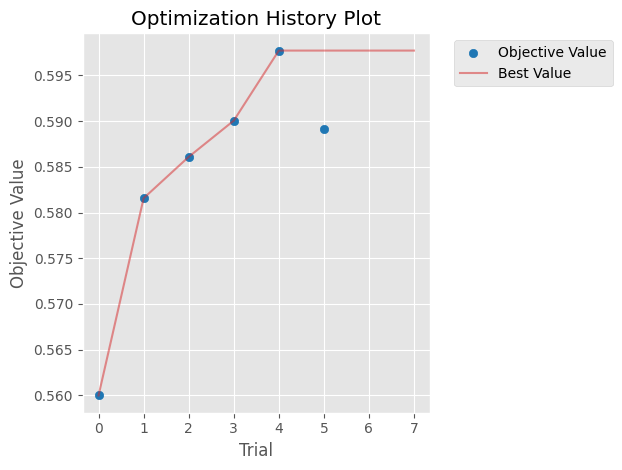

/tmp/ipykernel_1605495/400172520.py:6: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_fn(study)


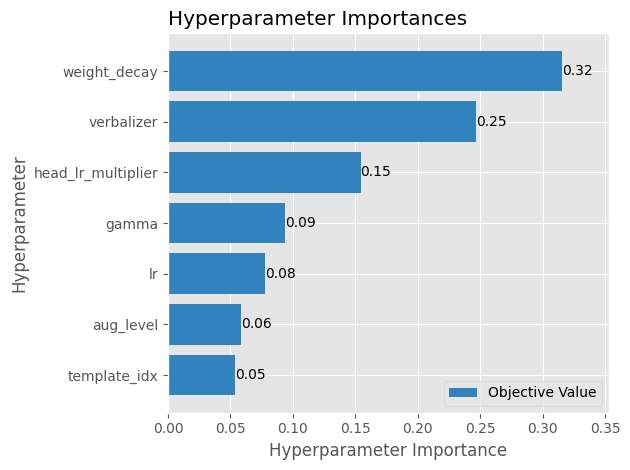

/tmp/ipykernel_1605495/400172520.py:6: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  plot_fn(study)


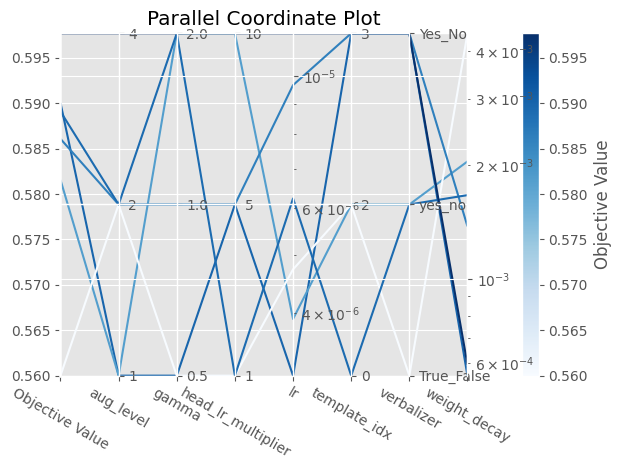

2026-03-04 08:46:37,522 INFO:	HTTP Request: HEAD https://huggingface.co/roberta-large/resolve/main/config.json "HTTP/1.1 200 OK"
Loading weights: 100%|██████████| 394/394 [00:01<00:00, 279.84it/s, Materializing param=roberta.encoder.layer.23.output.dense.weight]              
RobertaForMaskedLM LOAD REPORT from: roberta-large
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-04 08:46:39,689 INFO:	Verbalizer model loaded: RobertaForMaskedLM, n_pos=1, n_neg=1, pos_ids=[9904], neg_ids=[3084]
2026-03-04 08:46:39,690 INFO:	  backbone attr: .None, head attr: .None
2026-03-04 08:46:55,924 WARNING:	Sample 1307: [MASK] token was truncated (text may be too long for max_length=256). Falling back to position 0.
2026-03-04 08:46:55,931 WARNING:	Sample 1734: [MASK] token 

Augmentation level 4, old train size: 7118, new train size: 9818

N_VERBALIZER — Dev Set Results (threshold=0.275)
              precision    recall  f1-score   support

     Non-PCL       0.96      0.94      0.95      1894
         PCL       0.51      0.60      0.55       199

    accuracy                           0.91      2093
   macro avg       0.73      0.77      0.75      2093
weighted avg       0.91      0.91      0.91      2093

  Verbalizer: Yes_No
    pos words: ['Yes']  -> ids [9904]
    neg words: ['No']  -> ids [3084]
  Template: "Does the following text contain patronising language? "{text}" Answer: {mask}"
  lr: 1.1811371850121264e-05
  weight_decay: 0.0005929453342787635
  head_lr_multiplier: 10
  verbalizer: Yes_No
  template_idx: 3
  gamma: 2.0
  aug_level: 4


In [7]:
for plot_fn, suffix in [
    (plot_optimization_history, "history"),
    (plot_param_importances, "importances"),
    (plot_parallel_coordinate, "parallel"),
]:
    plot_fn(study)
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/{EXP_NAME}_optuna_{suffix}.png", dpi=300)
    plt.show()

# Reload best model and evaluate on dev set
best = study.best_trial
best_params = best.params
verbalizer_name = best_params["verbalizer"]
template = TEMPLATE_OPTIONS[best_params["template_idx"]]
pos_ids, neg_ids = VERBALIZER_CACHE[verbalizer_name]

model = PCLVerbalizer(
    pos_verbalizer_ids=pos_ids,
    neg_verbalizer_ids=neg_ids,
    model_name=MODEL_NAME,
).to(DEVICE)

state_dict = torch.load(
    os.path.join(MODEL_OUT_DIR, f"exp_{EXP_NAME}_best_model.pt"), map_location=DEVICE
)
model.load_state_dict(state_dict)

_, _, dev_loader = make_verbalizer_aug_dataloaders(template, aug_level=best_params["aug_level"])
dev_metrics = evaluate(model, DEVICE, dev_loader, threshold=best.user_attrs["best_threshold"])

print(f"\n{'='*60}")
print(f"{EXP_NAME.upper()} — Dev Set Results (threshold={best.user_attrs['best_threshold']:.3f})")
print(f"{'='*60}")
print(classification_report(dev_metrics["labels"], dev_metrics["preds"], target_names=["Non-PCL", "PCL"]))

# Show verbalizer details
verb_set = [v for v in VERBALIZER_SETS if v[0] == verbalizer_name][0]
print(f"  Verbalizer: {verbalizer_name}")
print(f"    pos words: {verb_set[1]}  -> ids {pos_ids}")
print(f"    neg words: {verb_set[2]}  -> ids {neg_ids}")
print(f"  Template: \"{template}\"")
for param_k, param_v in best_params.items():
    print(f"  {param_k}: {param_v}")

del model
gc.collect()
torch.cuda.empty_cache()